# Zero-Dependency Quality Workflows

In this notebook, you'll learn how to:
1. Understand how Kota's local Git hooks enforce code quality before commits leave your machine
2. Simulate the commit-msg validation regex to see which messages pass or fail
3. Visualize a hypothetical CI pipeline timeline showing where each gate catches errors
4. Examine the full PR lifecycle from local hook → GitHub Actions → merge

## Setup: The Hook Architecture

Kota uses **native Bash scripts** in `.githooks/` instead of Node.js (`husky`) or Python (`pre-commit`) frameworks. This means zero external dependencies for contributors.

The hooks are activated by running:
```bash
git config core.hooksPath .githooks
```

Two hooks are in play:
- `.githooks/pre-commit` → Runs `cargo fmt`, `cargo clippy`, `ruff check`
- `.githooks/commit-msg` → Validates the commit message against Conventional Commits regex

In [1]:
import re

# --- The exact regex from .githooks/commit-msg ---
PATTERN = r"^(feat|fix|docs|style|refactor|perf|test|chore|ci|build|revert)(\([a-z0-9\-]+\))?: .+"


def validate_commit(msg: str) -> bool:
    """Returns True if the commit message is valid Conventional Commits."""
    if msg.startswith("Merge"):
        return True
    return bool(re.match(PATTERN, msg))


# --- Test suite: which messages pass? ---
test_messages = [
    "feat(sensing): add network telemetry",
    "fix: resolve DNS leak detection edge case",
    "docs(notebooks): document telemetry and ci workflows",
    "style: apply cargo fmt",
    "chore: ignore generator scripts",
    "ci: add local githooks and semantic pr linting",
    "refactor(tui): extract status bar into component",
    "Merge branch 'dev' into main",
    # These should FAIL:
    "added network telemetry",
    "Update events.rs",
    "WIP",
    "FEAT: uppercase type",
    "feat:missing space",
    "fix(CAPS): uppercase scope",
]

print("\u2500\u2500 Commit Message Validation \u2500\u2500")
print(f"{'Message':<55} {'Result'}")
print("\u2500" * 65)
for msg in test_messages:
    valid = validate_commit(msg)
    icon = "\u2705" if valid else "\u274c"
    print(f"{msg:<55} {icon} {'PASS' if valid else 'BLOCKED'}")

── Commit Message Validation ──
Message                                                 Result
─────────────────────────────────────────────────────────────────
feat(sensing): add network telemetry                    ✅ PASS
fix: resolve DNS leak detection edge case               ✅ PASS
docs(notebooks): document telemetry and ci workflows    ✅ PASS
style: apply cargo fmt                                  ✅ PASS
chore: ignore generator scripts                         ✅ PASS
ci: add local githooks and semantic pr linting          ✅ PASS
refactor(tui): extract status bar into component        ✅ PASS
Merge branch 'dev' into main                            ✅ PASS
added network telemetry                                 ❌ BLOCKED
Update events.rs                                        ❌ BLOCKED
WIP                                                     ❌ BLOCKED
FEAT: uppercase type                                    ❌ BLOCKED
feat:missing space                                      ❌ BLOCKED
fix(C

## Visualizing the Quality Pipeline

Kota's quality system operates at three layers. The diagram below shows the full lifecycle of a code change, from local editing to merged PR. Each gate catches a different class of error:

1. **Local Pre-Commit** (instant feedback): Formatting, linting, type errors
2. **Local Commit-Msg** (instant feedback): Malformed commit messages
3. **GitHub Actions CI** (cloud feedback): Full test suite, cross-platform checks
4. **PR Title Lint** (cloud feedback): Semantic PR title validation before merge

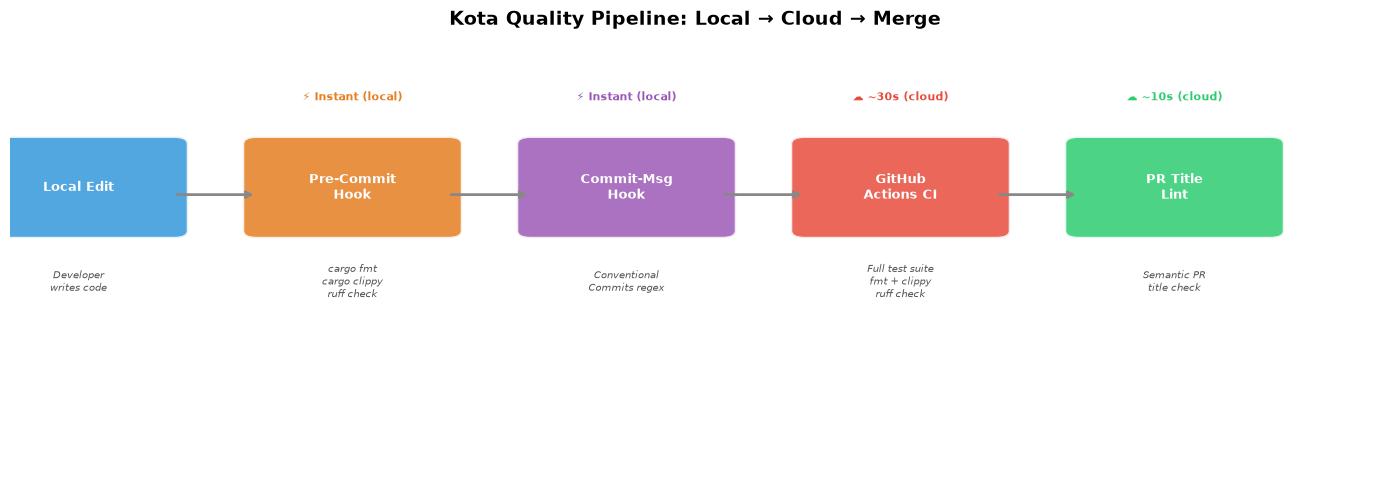

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 10)
ax.set_ylim(-1, 5)
ax.axis("off")
fig.suptitle(
    "Kota Quality Pipeline: Local → Cloud → Merge", fontsize=14, fontweight="bold"
)

# --- Pipeline stages ---
stages = [
    (0.5, 3, "Local Edit", "#3498DB", "Developer\nwrites code"),
    (2.5, 3, "Pre-Commit\nHook", "#E67E22", "cargo fmt\ncargo clippy\nruff check"),
    (4.5, 3, "Commit-Msg\nHook", "#9B59B6", "Conventional\nCommits regex"),
    (
        6.5,
        3,
        "GitHub\nActions CI",
        "#E74C3C",
        "Full test suite\nfmt + clippy\nruff check",
    ),
    (8.5, 3, "PR Title\nLint", "#2ECC71", "Semantic PR\ntitle check"),
]

for x, y, label, color, detail in stages:
    rect = mpatches.FancyBboxPatch(
        (x - 0.7, y - 0.5),
        1.4,
        1.2,
        boxstyle="round,pad=0.1",
        facecolor=color,
        alpha=0.85,
        edgecolor="white",
        linewidth=2,
    )
    ax.add_patch(rect)
    ax.text(
        x,
        y + 0.1,
        label,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white",
    )
    ax.text(
        x,
        y - 1.2,
        detail,
        ha="center",
        va="center",
        fontsize=7.5,
        color="#555",
        style="italic",
    )

# Arrows between stages
for i in range(len(stages) - 1):
    x1 = stages[i][0] + 0.7
    x2 = stages[i + 1][0] - 0.7
    ax.annotate(
        "",
        xy=(x2, 3),
        xytext=(x1, 3),
        arrowprops=dict(arrowstyle="->", color="#888", lw=2),
    )

# Labels for feedback speed
ax.text(
    2.5,
    4.3,
    "⚡ Instant (local)",
    ha="center",
    fontsize=8,
    color="#E67E22",
    fontweight="bold",
)
ax.text(
    4.5,
    4.3,
    "⚡ Instant (local)",
    ha="center",
    fontsize=8,
    color="#9B59B6",
    fontweight="bold",
)
ax.text(
    6.5,
    4.3,
    "☁️ ~30s (cloud)",
    ha="center",
    fontsize=8,
    color="#E74C3C",
    fontweight="bold",
)
ax.text(
    8.5,
    4.3,
    "☁️ ~10s (cloud)",
    ha="center",
    fontsize=8,
    color="#2ECC71",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

## Simulating a CI Run

Below, we simulate a full CI pipeline run (mirroring `.github/workflows/ci.yml`) to show what passes and fails across the Rust and Python jobs:

In [3]:
def simulate_ci_run(
    commit_msg: str, fmt_ok=True, clippy_ok=True, tests_ok=True, ruff_ok=True
):
    """Simulate Kota's CI pipeline for a given commit."""
    print(f"\n\u2550\u2550 Kota CI: Simulating push of '{commit_msg}' \u2550\u2550")
    print()

    # Job 1: Rust Checks
    print(
        "\u250c\u2500 Job: Rust Checks & Tests \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510"
    )
    checks = [
        ("cargo fmt --all -- --check", fmt_ok),
        ("cargo clippy --all-targets -- -D warnings", clippy_ok),
        ("cargo test --all-features", tests_ok),
    ]
    job1_pass = True
    for cmd, ok in checks:
        icon = "\u2705" if ok else "\u274c"
        status = "passed" if ok else "FAILED"
        print(f"\u2502  {icon} {cmd:<45} {status}")
        if not ok:
            job1_pass = False
    result1 = "\u2705 PASSED" if job1_pass else "\u274c FAILED"
    print(f"\u2514\u2500 Result: {result1}")
    print()

    # Job 2: Python Linting
    print(
        "\u250c\u2500 Job: Python Linting \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510"
    )
    icon = "\u2705" if ruff_ok else "\u274c"
    status = "passed" if ruff_ok else "FAILED"
    print(f"\u2502  {icon} {'ruff check .':<45} {status}")
    result2 = "\u2705 PASSED" if ruff_ok else "\u274c FAILED"
    print(f"\u2514\u2500 Result: {result2}")

    overall = job1_pass and ruff_ok
    print(f"\n{'\u2550' * 55}")
    print(
        f"  Overall: {'\u2705 All checks passed!' if overall else '\u274c Some checks failed.'}"
    )
    print(f"{'\u2550' * 55}")
    return overall


# Run 1: Everything passes (like our latest commit)
simulate_ci_run("feat(sensing): add network telemetry")

# Run 2: Formatting fails (like the bug we just fixed)
simulate_ci_run("feat: add sensing without formatting", fmt_ok=False)

# Run 3: Clippy warning
simulate_ci_run("fix: unused variable warning", clippy_ok=False)

SyntaxError: f-string expression part cannot include a backslash (827006774.py, line 35)

## The Conventional Commits Standard

Here is a quick reference for the commit types enforced by both the local `commit-msg` hook and the `pr-title.yml` GitHub Action:

| Type | Purpose | Example |
|---|---|---|
| `feat` | New feature | `feat(sensing): add network telemetry` |
| `fix` | Bug fix | `fix: resolve DNS leak edge case` |
| `docs` | Documentation only | `docs(notebooks): split features into L5 and L6` |
| `style` | Formatting, no logic change | `style: apply cargo fmt` |
| `refactor` | Code restructuring | `refactor(tui): extract status bar` |
| `perf` | Performance improvement | `perf(llm): batch token processing` |
| `test` | Adding/fixing tests | `test(skills): add SkillComposer unit test` |
| `chore` | Maintenance tasks | `chore: ignore generator scripts` |
| `ci` | CI/CD configuration | `ci: add local githooks` |
| `build` | Build system changes | `build: update sysinfo to 0.33` |
| `revert` | Reverting a commit | `revert: undo sensing threshold change` |

## Summary

In this notebook, you:

- Tested the Conventional Commits regex validator against 14 sample messages, seeing exactly which patterns pass and which are blocked
- Visualized the full quality pipeline from local editing through to PR merge, showing the four defensive gates
- Simulated three CI runs with different failure scenarios (formatting, clippy warnings) to understand what each check catches
- Referenced the complete Conventional Commits type table used by both the local hooks and GitHub Actions